In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# Determine if integrator will be slew rate limited
# H(s) = -1/sRC
# Vo/Vi = 1/sRC
# Vo(t) = Vi * t/RC
# Worst case input is 5V
# dVo/dt = Vi/RC
R = 10e3
C = 100e-12

n = 1
# nR = value of feedback resistor from output into delta-sigma

Vin = 1 + 2.5/n
SR = Vin/(R*C)
fc = 1/(2*np.pi*R*C)
print(f"SR={SR*1e-6:.3f}V/uS, fc={fc/1000:.2f}kHz")

# Calculate if the op amp integrator will reach saturation
f_clock = 2e6
Vmax = SR/f_clock
print(f"Vmax={Vmax:.2f}V")

# Determine high-pass filter cutoff of capacitive barrier
R = 100e3
C = 1e-9
fc = 1/(2*np.pi*R*C)
print(f"f_barrier={fc/1000:.2f}kHz")

# Calculate the potential max clock speed 
Tdelay = 80e-9
fdelay = 1/Tdelay
print(f"f_delay={fdelay*1e-6:.2f}MHz")

SR=3.500V/uS, fc=159.15kHz
Vmax=1.75V
f_barrier=1.59kHz
f_delay=12.50MHz


In [4]:
# Transfer function of integrator is
# (Vin-0)/R = (0-Vout)/(1/sC)
# Vout/Vin = -1/sRC = -1/RC * 1/s
# H(s) = -1/RC * 1/s

# https://www.analog.com/en/technical-articles/behind-the-sigma-delta-adc-topology.html
# Linearised model of delta-sigma modulator is 
# delta = x-y
# y = delta*H(s) + N

# x = input, y = quantised signal, N = quantisation noise
# y = (x-y)*H(s) + N
# y*(1+H(s)) = x*H(s) + N
# y = {H(s)/[1+H(s)]}*x + {1/[1+H(s)]}*N

# if y = Y/n
# Y = n*A(s)*x + n*B(s)*N

# A(s) = H(s)/[1+H(s)] = 1/(1+sRC)    <-- Low pass filter
# B(s) = 1/[1+H(s)]    = sRC/(1+sRC)  <-- High pass filter

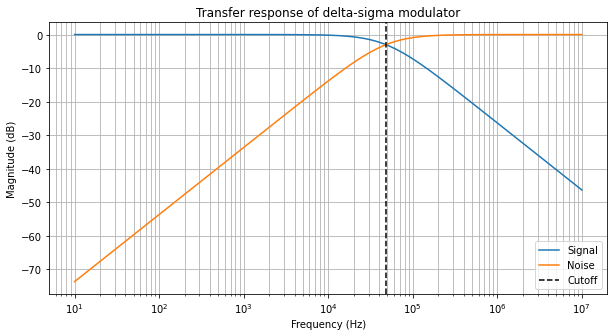

In [5]:
# First order delta-sigma modulator
R = 100e3
C = 33e-12
fc = 1/(2*np.pi*R*C)

f = np.logspace(1,7, 8*10)
w = 2*np.pi*f
s = 1j*w

H = 1/(s*R*C)
A = H/(1+H)
B = 1/(1+H)

A_mag = 20*np.log10(np.abs(A))
B_mag = 20*np.log10(np.abs(B))

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)
ax.plot(f, A_mag)
ax.plot(f, B_mag)
ax.axvline(fc, ls='--', color='black')
ax.set_xscale('log')
ax.grid(True, which='both')
ax.legend(["Signal", "Noise", "Cutoff"])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("Transfer response of delta-sigma modulator")
plt.show()

In [22]:
# Linearised model of second order delta-sigma modulator
# delta_1 = x-y
# delta_2 = H1(s)*delta_1 - y
# y = delta_2*H2(s) + N

# y = H1(s)*H2(s)*(x-y) - H2(s)*y + N
# y*[1 + H1(s)*H2(s) + H2(s)] = H1(s)*H2(s)*x + N
# y = A(s)*x + B(s)*N

# H1(s) = H2(s) = 1/sRC
# 1+H1(s)*H2(s) + H2(s) = 1 + 1/(sRC)^2 + 1/sRC = [(sRC)^2 + sRC + 1]/(sRC)^2
# A(s) =       1/[(sRC)^2 + sRC + 1]  <-- Second order low pass response
# B(s) = (sRC)^2/[(sRC)^2 + sRC + 1]  <-- Second order high pass response

In [23]:
# Second order response analysis
# A(s) = 1/(RC)^2  * 1/[s^2 + s/RC + 1/(RC)^2]
# wn = 1/RC
# 2*DF*wn = 1/RC
# DF = 1/2

# wn/Q = 1/RC
# Q = 1

# wn/Q = 2*DF*wn
# Q = 1/(2*DF)

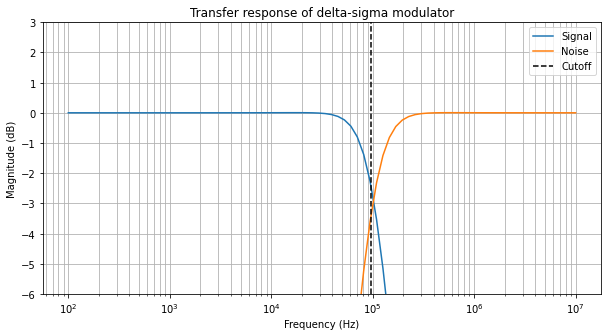

In [21]:
# Second order delta-sigma modulator
R = 50e3
C = 33e-12
fc = 1/(2*np.pi*R*C)

f = np.logspace(2,7, 8*10)
w = 2*np.pi*f
s = 1j*w

# move the responses so that we get a critically damped second order response
n = 0.32
H1 = 1/(s*R*C*(1+n))
H2 = 1/(s*R*C*(1-n))

A = (H1*H2)/(1+H2+H1*H2)
B = 1/(1+H2+H1*H2)

A_mag = 20*np.log10(np.abs(A))
B_mag = 20*np.log10(np.abs(B))

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)
ax.plot(f, A_mag)
ax.plot(f, B_mag)
ax.axvline(fc, ls='--', color='black')
ax.set_xscale('log')
ax.grid(True, which='both')
ax.legend(["Signal", "Noise", "Cutoff"])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("Transfer response of delta-sigma modulator")
ax.set_ylim([-6,3])
plt.show()